# Chaos Agent (HuggingFace-driven)

This notebook defines a configurable Chaos Agent for property graphs, with optional HuggingFace model guidance.
It operates on `networkx.MultiDiGraph` and injects realistic, systematic corruptions.

What it does
- Builds corruption plans from a small catalog (schema drift, ID collision, entity merge/split, neighbor rewiring).
- Can use a HuggingFace text-generation model to choose which corruption ops to apply.
- Falls back to randomized planning if no model is provided or the model is unavailable.

Dependencies (install as needed)
- `networkx`
- `transformers` (optional, for LLM-guided corruption planning)

## Setup / imports

In [50]:
import random
import csv
import json
from dataclasses import dataclass
from typing import Any, Dict, List, Optional
import matplotlib.pyplot as plt
from pathlib import Path

import networkx as nx

try:
    from transformers import pipeline
except Exception:
    pipeline = None

from collections import Counter
import re


## Graph utilities

In [51]:
def graph_summary(g: nx.MultiDiGraph) -> str:
    labels: Dict[str, int] = {}

    for _, data in g.nodes(data=True):
        label = data.get("label", "Unknown")
        labels[label] = labels.get(label, 0) + 1
        
    label_items = sorted(labels.items(), key=lambda x: (-x[1], x[0]))
    label_str =  ",".join([f"{k}:{v}" for k, v in label_items])

    return f"nodes={g.number_of_nodes()}, edges={g.number_of_edges()}, labels=[{label_str}]"



OUTPUT_DIR = Path("corrupted_graphs")
OUTPUT_DIR.mkdir(exist_ok=True)
LOG_DIR = OUTPUT_DIR / "logs"
LOG_DIR.mkdir(exist_ok=True)

def save_graph(g: nx.MultiDiGraph, filename: str) -> None:
    data = {
        "nodes": [{"id": n, **g.nodes[n]} for n in g.nodes()],
        "edges": [{"src": u, "dst": v, **d} for u, v, d in g.edges(data=True)],
    }
    
    complete_path = OUTPUT_DIR / filename

    with open(complete_path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2)

def save_corruption_log(ops, results, filename: str) -> None:
    data = {
        "ops": [{"kind": op.kind, "params": op.params} for op in ops],
        "results": results,
    }

    complete_path = complete_path = LOG_DIR / filename

    with open(complete_path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2)

## Constraint framework

In [52]:
@dataclass
class Constraint:
    name: str
    description: str
    check: Any  # Callable[[nx.MultiDiGraph], List[Dict[str, Any]]]


def violations(g: nx.MultiDiGraph, C: List[Constraint]) -> Dict[str, List[Dict[str, Any]]]:
    """Return a dict: constraint_name -> list of violation records."""
    out: Dict[str, List[Dict[str, Any]]] = {}
    for c in C:
        try:
            v = c.check(g) or []
        except Exception as e:
            v = [{"error": str(e)}]
        out[c.name] = v
    return out


def violation_score(g: nx.MultiDiGraph, C: List[Constraint]) -> int:
    """Scalar objective: total number of violations across all constraints."""
    v = violations(g, C)
    return sum(len(items) for items in v.values())


# --------
# Helpers
# --------
def make_unique_node_attr_constraint(attr: str = "id") -> Constraint:
    def _check(g: nx.MultiDiGraph) -> List[Dict[str, Any]]:
        seen: Dict[Any, List[Any]] = {}
        for n, data in g.nodes(data=True):
            if attr in data:
                seen.setdefault(data[attr], []).append(n)
        out: List[Dict[str, Any]] = []
        for val, nodes in seen.items():
            if val is None:
                continue
            if len(nodes) > 1:
                out.append({"attr": attr, "value": val, "nodes": nodes})
        return out
    return Constraint(
        name=f"unique_node_attr:{attr}",
        description=f"Node attribute '{attr}' should be unique when present.",
        check=_check,
    )


def make_edge_domain_range_constraint(
    relation: str,
    src_label: str,
    dst_label: str,
    relation_attr: str = "relation",
) -> Constraint:
    def _check(g: nx.MultiDiGraph) -> List[Dict[str, Any]]:
        out: List[Dict[str, Any]] = []
        for u, v, k, data in g.edges(keys=True, data=True):
            if data.get(relation_attr) != relation:
                continue
            lu = g.nodes[u].get("label")
            lv = g.nodes[v].get("label")
            if lu != src_label or lv != dst_label:
                out.append({
                    "u": u, "v": v, "key": k,
                    "relation": relation,
                    "src_label": lu, "dst_label": lv,
                    "expected_src": src_label, "expected_dst": dst_label,
                })
        return out
    return Constraint(
        name=f"domain_range:{relation}",
        description=f"Edges '{relation}' must be {src_label} -> {dst_label}.",
        check=_check,
    )

def make_max_out_degree_constraint(
    relation: str,
    max_deg: int,
    src_label: str | None = None,
):
    """
    Enforces: for each node u (optionally with label src_label),
    out_degree(u, relation) <= max_deg
    """

    def check(g):
        violations = []
        out_deg = defaultdict(int)

        for u, v, data in g.edges(data=True):
            if data.get("relation") != relation:
                continue

            if src_label is not None:
                if g.nodes[u].get("label") != src_label:
                    continue

            out_deg[u] += 1

            if out_deg[u] > max_deg:
                violations.append({
                    "node": u,
                    "label": g.nodes[u].get("label"),
                    "relation": relation,
                    "out_degree": out_deg[u],
                    "max_allowed": max_deg,
                })

        return violations

    return Constraint(
        name=f"max_out_degree({relation})",
        description=f"Each {src_label or 'node'} has at most {max_deg} outgoing '{relation}' edges",
        check=check,
    )


In [53]:

# ---------------------------------------
# Default constraint pack builder
# ---------------------------------------
def default_constraints_for_graph(g: nx.MultiDiGraph) -> List[Constraint]:
    """Heuristic default C based on what appears in the current graph."""
    C: List[Constraint] = [make_unique_node_attr_constraint("id")]

    # Add a few common domain/range constraints only if the relation exists.
    rels = {data.get("relation") for _, _, data in g.edges(data=True)}
    mapping = {
        "WORKS_AT": ("Person", "Company"),
        "worksFor": ("Person", "Organization"),
        "birthPlace": ("Person", "Place"),
        "locatedIn": ("Place", "Place"),
    }
    for r, (s, t) in mapping.items():
        if r in rels:
            C.append(make_edge_domain_range_constraint(r, s, t))
    return C

# ---------------------------------------
# Dataset-specific constraint pack builders
# ---------------------------------------

def make_no_self_loop_constraint(relations: List[str]) -> Constraint:
    rel_set = set(relations)
    def _check(g: nx.MultiDiGraph) -> List[Dict[str, Any]]:
        out: List[Dict[str, Any]] = []
        for u, v, k, data in g.edges(keys=True, data=True):
            if data.get("relation") in rel_set and u == v:
                out.append({"node": u, "relation": data.get("relation")})
        return out
    return Constraint(
        name=f"no_self_loop[{','.join(relations)}]",
        description=f"No self-loop edges for relations: {relations}",
        check=_check,
    )

def make_symmetric_relation_constraint(relation: str) -> Constraint:
    def _check(g: nx.MultiDiGraph) -> List[Dict[str, Any]]:
        # For every (u->v), require at least one (v->u) of same relation
        out: List[Dict[str, Any]] = []
        # Build fast lookup for presence of reverse edge
        rel_edges = set()
        for u, v, data in g.edges(data=True):
            if data.get("relation") == relation:
                rel_edges.add((u, v))
        for (u, v) in rel_edges:
            if (v, u) not in rel_edges:
                out.append({"u": u, "v": v, "missing_reverse": True})
        return out
    return Constraint(
        name=f"symmetric[{relation}]",
        description=f"Relation {relation} should be symmetric.",
        check=_check,
    )

def make_transitive_relation_constraint(relation: str, sample_limit: int = 5000) -> Constraint:
    """
    If (a->b) and (b->c) then (a->c) should exist.
    We cap checks with sample_limit to keep runtime reasonable.
    """
    def _check(g: nx.MultiDiGraph) -> List[Dict[str, Any]]:
        out: List[Dict[str, Any]] = []
        # adjacency for this relation
        adj: Dict[Any, set] = {}
        for a, b, data in g.edges(data=True):
            if data.get("relation") == relation:
                adj.setdefault(a, set()).add(b)

        checked = 0
        for a, bs in adj.items():
            for b in bs:
                cs = adj.get(b)
                if not cs:
                    continue
                for c in cs:
                    if c == a:
                        continue
                    checked += 1
                    if checked > sample_limit:
                        return out
                    if c not in adj.get(a, set()):
                        out.append({"a": a, "b": b, "c": c, "missing_edge": (a, c)})
        return out

    return Constraint(
        name=f"transitive[{relation}]",
        description=f"Relation {relation} should be transitive (within sampling cap={sample_limit}).",
        check=_check,
    )

def _normalize_text(s: str) -> str:
    return re.sub(r"\s+", " ", (s or "").strip().lower())

def _normalize_phone(s: str) -> str:
    digits = re.sub(r"\D+", "", s or "")
    return digits

def _restaurant_attr_value(g: nx.MultiDiGraph, r_node: Any, relation: str) -> Optional[str]:
    # Restaurant -(relation)-> AttrNode(value=...)
    for _, v, data in g.out_edges(r_node, data=True):
        if data.get("relation") != relation:
            continue
        vdata = g.nodes[v]
        # In build_fz_graph, attribute nodes have {"label": Field.capitalize(), "value": value}
        val = vdata.get("value")
        if val:
            return str(val)
    return None

def make_fz_same_entity_city_majority_constraint(relation: str = "same_entity", min_majority: float = 0.7) -> Constraint:
    """
    For each connected component of Restaurant nodes connected via `same_entity` (undirected),
    require that a majority (>= min_majority) share the same normalized city.
    This is 'medium' difficulty: allows some noise/aliases.
    """
    def _check(g: nx.MultiDiGraph) -> List[Dict[str, Any]]:
        # Build undirected graph over Restaurant nodes using same_entity edges
        ug = nx.Graph()
        restaurants = [n for n, d in g.nodes(data=True) if d.get("label") == "Restaurant"]
        ug.add_nodes_from(restaurants)
        for u, v, data in g.edges(data=True):
            if data.get("relation") == relation and u in ug and v in ug:
                ug.add_edge(u, v)

        out: List[Dict[str, Any]] = []
        for comp in nx.connected_components(ug):
            comp = list(comp)
            if len(comp) < 2:
                continue
            cities = []
            for r in comp:
                city = _restaurant_attr_value(g, r, "city")
                if city:
                    cities.append(_normalize_text(city))
            if not cities:
                continue
            # majority vote
            counts = Counter(cities)
            top_city, top_cnt = counts.most_common(1)[0]
            if top_cnt / len(cities) < min_majority:
                out.append({
                    "component_size": len(comp),
                    "top_city": top_city,
                    "top_ratio": round(top_cnt/len(cities), 3),
                    "cities_sample": counts.most_common(3),
                })
        return out

    return Constraint(
        name=f"fz_city_majority[{relation}]",
        description=f"In each same-entity cluster, >= {min_majority:.0%} restaurants should share the same city.",
        check=_check,
    )

def make_fz_same_entity_phone_consistency_constraint(relation: str = "same_entity") -> Constraint:
    """
    For each same_entity pair (Restaurant->Restaurant), require phones to match after normalization,
    allowing a relaxed match on the last 7 digits (to tolerate formatting/country codes).
    """
    def _check(g: nx.MultiDiGraph) -> List[Dict[str, Any]]:
        out: List[Dict[str, Any]] = []
        seen_pairs = set()
        for u, v, data in g.edges(data=True):
            if data.get("relation") != relation:
                continue
            if g.nodes[u].get("label") != "Restaurant" or g.nodes[v].get("label") != "Restaurant":
                continue
            # avoid double counting in symmetric graphs
            key = tuple(sorted((u, v)))
            if key in seen_pairs:
                continue
            seen_pairs.add(key)

            p1 = _normalize_phone(_restaurant_attr_value(g, u, "phone") or "")
            p2 = _normalize_phone(_restaurant_attr_value(g, v, "phone") or "")
            if not p1 or not p2:
                continue
            if p1 == p2:
                continue
            # relaxed suffix match
            if len(p1) >= 7 and len(p2) >= 7 and p1[-7:] == p2[-7:]:
                continue
            out.append({"u": u, "v": v, "phone_u": p1, "phone_v": p2})
        return out

    return Constraint(
        name=f"fz_phone_consistency[{relation}]",
        description="same_entity pairs should have consistent normalized phone numbers (allow last-7-digit match).",
        check=_check,
    )

def constraints_for_dbpedia_medium() -> List[Constraint]:
    """
    Medium-difficulty constraints that match the relations present in dbpedia_graph.json:
    - domain/range constraints for key relations
    - functional constraint on headquarter
    - no self-loops
    - 'must-have at least one geo edge' for Company/Organisation
    """
    C: List[Constraint] = []
    C.append(make_edge_domain_range_constraint("headquarter", {"Company", "Organisation"}, {"City", "Location", "Place", "Country"}))
    C.append(make_max_out_degree_constraint("headquarter",1,"Company"))
    C.append(make_edge_domain_range_constraint("location", {"Company", "Organisation"}, {"City", "Location", "Place", "Country"}))
    C.append(make_no_self_loop_constraint(["location", "headquarter", "country"]))

    # must-have at least one geo edge
    def _must_have_geo(g: nx.MultiDiGraph) -> List[Dict[str, Any]]:
        out: List[Dict[str, Any]] = []
        geo_rels = {"location", "headquarter", "country"}
        for n, d in g.nodes(data=True):
            if d.get("label") not in {"Company", "Organisation"}:
                continue
            has = False
            for _, _, ed in g.out_edges(n, data=True):
                if ed.get("relation") in geo_rels:
                    has = True
                    break
            if not has:
                out.append({"node": n, "label": d.get("label"), "missing_any_of": sorted(geo_rels)})
        return out

    C.append(Constraint(
        name="company_has_geo_edge",
        description="Each Company/Organisation should have at least one of {location, headquarter, country}.",
        check=_must_have_geo,
    ))
    return C

def constraints_for_fz_medium() -> List[Constraint]:
    """
    Medium-difficulty constraints for the FZ ARFF-derived graph:
    - same_entity is symmetric
    - no self-loop on same_entity
    - transitivity on same_entity (sampled)
    - majority city consistency within same_entity clusters
    - phone consistency within same_entity pairs
    """
    C: List[Constraint] = []
    C.append(make_symmetric_relation_constraint("same_entity"))
    C.append(make_no_self_loop_constraint(["same_entity"]))
    C.append(make_transitive_relation_constraint("same_entity", sample_limit=4000))
    C.append(make_fz_same_entity_city_majority_constraint("same_entity", min_majority=0.7))
    C.append(make_fz_same_entity_phone_consistency_constraint("same_entity"))
    return C

def get_constraints_for_dataset(dataset: str) -> List[Constraint]:
    dataset = (dataset or "").lower().strip()
    if dataset in {"dbpedia", "dbpedia_json", "dbpedia_graph"}:
        return constraints_for_dbpedia_medium()
    if dataset in {"fz", "fz_arff", "fodors_zagat"}:
        return constraints_for_fz_medium()
    # fallback: minimal generic constraints
    return [make_no_self_loop_constraint(["location", "headquarter", "same_entity"])]


## Chaos operators

In [54]:
@dataclass
class CorruptionOp:
    kind: str
    params: Dict[str, Any]

# ---------------------------------------
# Chaos operators
# ---------------------------------------

def schema_drift(g: nx.MultiDiGraph, from_label: str, to_label: str, p: float = 1.0) -> int:
    changed = 0
    for _, data in g.nodes(data=True):
        if data.get("label") == from_label and random.random() <= p:
            data["label"] = to_label
            changed += 1
    return changed


def pipeline_id_collision(g: nx.MultiDiGraph, id_attr: str = "id") -> int:
    by_id: Dict[Any, List[Any]] = {}
    for n, data in g.nodes(data=True):
        if id_attr in data:
            by_id.setdefault(data[id_attr], []).append(n)
    collisions = [nodes for nodes in by_id.values() if len(nodes) > 1]
    if not collisions:
        return 0
    group = random.choice(collisions)
    keep = group[0]
    for other in group[1:]:
        _merge_nodes(g, keep, other)
    return len(group) - 1


def entity_merge(g: nx.MultiDiGraph, node_a: Any, node_b: Any) -> int:
    if node_a not in g or node_b not in g or node_a == node_b:
        return 0
    _merge_nodes(g, node_a, node_b)
    return 1


def _merge_nodes(g: nx.MultiDiGraph, keep: Any, drop: Any) -> None:
    keep_data = g.nodes[keep]
    drop_data = g.nodes[drop]
    for k, v in drop_data.items():
        if k not in keep_data:
            keep_data[k] = v
    for u, _, key, data in list(g.in_edges(drop, keys=True, data=True)):
        g.add_edge(u, keep, key=key, **data)
    for _, v, key, data in list(g.out_edges(drop, keys=True, data=True)):
        g.add_edge(keep, v, key=key, **data)
    g.remove_node(drop)


def entity_split(g: nx.MultiDiGraph, node: Any, split_ratio: float = 0.5) -> Optional[Any]:
    if node not in g:
        return None
    new_node = f"{node}_dup"
    if new_node in g:
        return None
    g.add_node(new_node, **g.nodes[node])
    in_edges = list(g.in_edges(node, keys=True, data=True))
    out_edges = list(g.out_edges(node, keys=True, data=True))
    random.shuffle(in_edges)
    random.shuffle(out_edges)
    move_in = in_edges[: int(len(in_edges) * split_ratio)]
    move_out = out_edges[: int(len(out_edges) * split_ratio)]
    for u, v, key, data in move_in:
        if g.has_edge(u, v, key):
            g.add_edge(u, new_node, key=key, **data)
            g.remove_edge(u, v, key)
    for u, v, key, data in move_out:
        if g.has_edge(u, v, key):
            g.add_edge(new_node, v, key=key, **data)
            g.remove_edge(u, v, key)
    return new_node


def adversarial_neighbor_rewire(g: nx.MultiDiGraph, node: Any, k: int = 2) -> int:
    if node not in g:
        return 0
    out_edges = list(g.out_edges(node, keys=True, data=True))
    if not out_edges:
        return 0
    random.shuffle(out_edges)
    rewired = 0
    candidates = list(g.nodes())
    for u, v, key, data in out_edges[:k]:
        new_v = random.choice(candidates)
        if new_v == v:
            continue
        g.add_edge(u, new_v, key=key, **data)
        g.remove_edge(u, v, key)
        rewired += 1
    return rewired


def constraint_targeted(g: nx.MultiDiGraph, constraint_fn, trials: int = 50) -> Optional[CorruptionOp]:
    best_op = None
    best_score = None
    nodes = list(g.nodes())
    if not nodes:
        return None
    for _ in range(trials):
        node = random.choice(nodes)
        op = CorruptionOp("adversarial_neighbor_rewire", {"node": node, "k": 1})
        g_copy = g.copy()
        adversarial_neighbor_rewire(g_copy, **op.params)
        score = constraint_fn(g_copy)
        if best_score is None or score > best_score:
            best_score = score
            best_op = op
    return best_op


## ChaosAgent

In [55]:
class ChaosAgent:
    def __init__(
        self,
        model_name: Optional[str] = None,
        seed: int = 7,
        constraints: Optional[List[Constraint]] = None,
        allowed_ops: Optional[List[str]] = None,
    ) -> None:
        self.rng = random.Random(seed)
        self.model_name = model_name
        self.generator = None

        # Constraint set C (can be passed in; otherwise inferred per-graph in plan())
        self.constraints = constraints
        # Allow-list for corruption operators (controls what kinds of corruptions are permitted)
        self.allowed_ops = allowed_ops

        if model_name and pipeline is not None:
            try:
                self.generator = pipeline("text-generation", model=model_name)
            except Exception:
                self.generator = None

    def plan(
        self,
        g: nx.MultiDiGraph,
        max_ops: int = 3,
        constraints: Optional[List[Constraint]] = None,
        allowed_ops: Optional[List[str]] = None,
        trials: int = 25,
        objective: str = "maximize_violations",
    ) -> List[CorruptionOp]:
        """Create a corruption plan.

        - If an HF generator exists, we *start* from its suggestion (or fall back to random).
        - If constraints are provided, we optionally do a black-box search over candidate plans
          and pick the plan that maximizes violation_score(G', C) under the same budget.
        """
        C = constraints or self.constraints or default_constraints_for_graph(g)
        ops_allow = allowed_ops or self.allowed_ops

        # 1) Base candidate plan from HF (if available) or random.
        base_plan = None
        if self.generator is None:
            base_plan = self._random_plan(g, max_ops, ops_allow)
        else:
            prompt = (
                "You are a chaos agent for property graphs. Choose up to "
                f"{max_ops} corruption operations from this list: "
                "schema_drift, pipeline_id_collision, entity_merge, entity_split, "
                "adversarial_neighbor_rewire."
                f"Graph summary: {graph_summary(g)}"
                "Return a comma-separated list of operation names only."
            )
            try:
                out = self.generator(prompt, max_new_tokens=20, do_sample=True)
                text = out[0]["generated_text"]
                chosen = []
                for name in [
                    "schema_drift",
                    "pipeline_id_collision",
                    "entity_merge",
                    "entity_split",
                    "adversarial_neighbor_rewire",
                ]:
                    if name in text:
                        chosen.append(name)
                if chosen:
                    base_plan = [self._default_op(g, name) for name in chosen[:max_ops]]
                else:
                    base_plan = self._random_plan(g, max_ops, ops_allow)
            except Exception:
                base_plan = self._random_plan(g, max_ops, ops_allow)

        if objective != "maximize_violations":
            return self._filter_allowed(base_plan, ops_allow)[:max_ops]

        # 2) If we have constraints, refine via black-box search:
        #    sample multiple candidate plans and keep the one with best violation score.
        best_ops = self._filter_allowed(base_plan, ops_allow)[:max_ops]
        best_score = self._score_after_plan(g, best_ops, C)

        for _ in range(max(0, trials - 1)):
            cand = self._random_plan(g, max_ops, ops_allow)
            cand = self._filter_allowed(cand, ops_allow)[:max_ops]
            s = self._score_after_plan(g, cand, C)
            if s > best_score:
                best_score, best_ops = s, cand

        return best_ops

    def apply(
        self,
        g: nx.MultiDiGraph,
        ops: List[CorruptionOp],
        constraints: Optional[List[Constraint]] = None,
        only_if_increases_violations: bool = False,
    ) -> Dict[str, int]:
        """Apply a corruption plan.

        If only_if_increases_violations=True, we will only apply an op if it
        strictly increases violation_score w.r.t. the provided constraint set C.
        """
        C = constraints or self.constraints or default_constraints_for_graph(g)
        results: Dict[str, int] = {}

        for op in ops:
            if only_if_increases_violations:
                before = violation_score(g, C)
                g_try = g.copy()
                self._apply_one(g_try, op)
                after = violation_score(g_try, C)
                if after <= before:
                    results[f"SKIP:{op.kind}"] = 0
                    continue  # skip this op

            results[op.kind] = self._apply_one(g, op)

        return results

    # -----------------------
    # Internal helper methods
    # -----------------------
    def _apply_one(self, g: nx.MultiDiGraph, op: CorruptionOp) -> int:
        if op.kind == "schema_drift":
            return schema_drift(g, **op.params)
        if op.kind == "pipeline_id_collision":
            return pipeline_id_collision(g, **op.params)
        if op.kind == "entity_merge":
            return entity_merge(g, **op.params)
        if op.kind == "entity_split":
            new_node = entity_split(g, **op.params)
            return 1 if new_node else 0
        if op.kind == "adversarial_neighbor_rewire":
            return adversarial_neighbor_rewire(g, **op.params)
        return 0

    def _random_plan(
        self,
        g: nx.MultiDiGraph,
        max_ops: int,
        allowed_ops: Optional[List[str]] = None,
    ) -> List[CorruptionOp]:
        op_names = [
            "schema_drift",
            "pipeline_id_collision",
            "entity_merge",
            "entity_split",
            "adversarial_neighbor_rewire",
        ]
        if allowed_ops is not None:
            op_names = [n for n in op_names if n in set(allowed_ops)]
        self.rng.shuffle(op_names)
        return [self._default_op(g, name) for name in op_names[:max_ops]]

    def _filter_allowed(
        self,
        ops: List[CorruptionOp],
        allowed_ops: Optional[List[str]],
    ) -> List[CorruptionOp]:
        if allowed_ops is None:
            return ops
        allow = set(allowed_ops)
        return [op for op in ops if op.kind in allow]

    def _score_after_plan(self, g: nx.MultiDiGraph, ops: List[CorruptionOp], C: List[Constraint]) -> int:
        g_copy = g.copy()
        for op in ops:
            self._apply_one(g_copy, op)
        return violation_score(g_copy, C)

    def _default_op(self, g: nx.MultiDiGraph, name: str) -> CorruptionOp:
        nodes = list(g.nodes())
        labels = list({g.nodes[n].get("label", "Unknown") for n in nodes})
        if name == "schema_drift":
            from_label = labels[0] if labels else "Company"
            to_label = labels[1] if len(labels) > 1 else "Organization"
            return CorruptionOp(name, {"from_label": from_label, "to_label": to_label, "p": 1.0})
        if name == "pipeline_id_collision":
            return CorruptionOp(name, {"id_attr": "id"})
        if name == "entity_merge":
            if len(nodes) < 2:
                return CorruptionOp(name, {"node_a": None, "node_b": None})
            return CorruptionOp(name, {"node_a": nodes[0], "node_b": nodes[1]})
        if name == "entity_split":
            node = nodes[0] if nodes else None
            return CorruptionOp(name, {"node": node, "split_ratio": 0.5})
        if name == "adversarial_neighbor_rewire":
            node = nodes[0] if nodes else None
            return CorruptionOp(name, {"node": node, "k": 2})
        return CorruptionOp(name, {})

## Graph helpers

In [56]:
def draw_graph(g: nx.MultiDiGraph, title: str, pos=None) -> dict:
    if pos is None:
        pos = nx.spring_layout(g, seed=42)
    else:
        pos = {n: p for n, p in pos.items() if n in g}
        pos = nx.spring_layout(g, pos=pos, fixed=list(pos.keys()), seed=42)

    labels = {n: g.nodes[n].get("label", str(n)) for n in g.nodes()}
    plt.figure(figsize=(6, 4))
    nx.draw_networkx_nodes(g, pos, node_size=700, node_color="#cfe8ff", edgecolors="#1f4f8b")
    nx.draw_networkx_edges(g, pos, arrowstyle="->", arrowsize=12, edge_color="#1f4f8b")
    nx.draw_networkx_labels(g, pos, labels=labels, font_size=9)
    plt.title(title)
    plt.axis("off")
    return pos


def graph_diff_view(g_before: nx.MultiDiGraph, g_after: nx.MultiDiGraph, title: str, pos=None) -> dict:
    if pos is None:
        # Layout on union graph so both views share positions
        g_union = nx.compose(g_before, g_after)
        pos = nx.spring_layout(g_union, seed=42)

    # Node colors: highlight label changes
    node_colors = []
    for n in g_after.nodes():
        if n in g_before.nodes() and g_before.nodes[n].get("label") != g_after.nodes[n].get("label"):
            node_colors.append("#f5a623")  # changed label
        else:
            node_colors.append("#cfe8ff")

    # Edge sets for diff
    def edge_key(u, v, data):
        return (u, v, data.get("relation"))

    before_edges = {edge_key(u, v, d) for u, v, d in g_before.edges(data=True)}
    after_edges = {edge_key(u, v, d) for u, v, d in g_after.edges(data=True)}

    added = after_edges - before_edges
    removed = before_edges - after_edges
    kept = before_edges & after_edges

    def draw_edges(edge_set, color, style="solid"):
        edgelist = [(u, v) for u, v, _ in edge_set]
        nx.draw_networkx_edges(g_after, pos, edgelist=edgelist, edge_color=color, style=style, arrows=True)

    labels = {n: g_after.nodes[n].get("label", str(n)) for n in g_after.nodes()}

    plt.figure(figsize=(7, 5))
    nx.draw_networkx_nodes(g_after, pos, node_size=700, node_color=node_colors, edgecolors="#1f4f8b")
    nx.draw_networkx_labels(g_after, pos, labels=labels, font_size=9)

    draw_edges(kept, "#1f4f8b", "solid")     # unchanged
    draw_edges(added, "#2ca02c", "solid")    # added
    draw_edges(removed, "#d62728", "dashed") # removed

    plt.title(title)
    plt.axis("off")
    return pos

def changed_nodes(g_before, g_after):
    changed = set()
    for n in g_after.nodes():
        if n not in g_before:
            changed.add(n)
        elif g_before.nodes[n].get("label") != g_after.nodes[n].get("label"):
            changed.add(n)
    return changed

def subgraph_around_changes(g_before, g_after, radius=1):
    changed = changed_nodes(g_before, g_after)
    if not changed:
        return g_before.subgraph([]).copy(), g_after.subgraph([]).copy()

    nodes = set()
    for n in changed:
        nodes.add(n)
        nodes.update(nx.ego_graph(g_after, n, radius=radius, undirected=True).nodes())
    return g_before.subgraph(nodes).copy(), g_after.subgraph(nodes).copy()

## Dataset loaders

In [57]:
# -----------------------
# DPPedia data loader
# -----------------------
def load_dbpedia_graph(path: str) -> nx.MultiDiGraph:
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    g = nx.MultiDiGraph()
    for node in data.get("nodes", []):
        g.add_node(node["id"], **{k: v for k, v in node.items() if k != "id"})
    for edge in data.get("edges", []):
        g.add_edge(edge["src"], edge["dst"], relation=edge.get("type"))
    return g

def sample_subgraph(g: nx.MultiDiGraph, k: int = 50) -> nx.MultiDiGraph:
    nodes = list(g.nodes())
    if len(nodes) <= k:
        return g
    seed = random.choice(nodes)
    sub = nx.ego_graph(g, seed, radius=2, undirected=True)
    return g.subgraph(sub.nodes()).copy()

# -----------------------
# FZ data loader
# -----------------------

def load_fz_arff(path: str) -> List[Dict[str, str]]:
    attrs: List[str] = []
    rows: List[Dict[str, str]] = []
    in_data = False
    with open(path, "r", encoding="utf-8") as f:
        for raw in f:
            line = raw.strip()
            if not line or line.startswith("%"):
                continue
            if not in_data:
                lower = line.lower()
                if lower.startswith("@attribute"):
                    parts = line.split(None, 2)
                    if len(parts) >= 2:
                        attrs.append(parts[1])
                elif lower.startswith("@data"):
                    in_data = True
                continue
            for row in csv.reader([line], skipinitialspace=True):
                values = [v.strip().strip("\"'") for v in row]
            if len(values) != len(attrs):
                continue
            rows.append(dict(zip(attrs, values)))
    return rows

def build_fz_graph(rows: List[Dict[str, str]]) -> nx.MultiDiGraph:
    g = nx.MultiDiGraph()
    attr_fields = ["name", "addr", "city", "phone", "type"]
    for idx, row in enumerate(rows):
        row_copy = dict(row)
        entity_id = row_copy.pop("class", None)
        node_id = f"fz_{idx}"
        g.add_node(node_id, label="Restaurant", entity_id=entity_id)
        for field in attr_fields:
            value = row_copy.get(field)
            if not value:
                continue
            attr_node_id = f"{field}:{value}"
            if attr_node_id not in g:
                g.add_node(attr_node_id, label=field.capitalize(), value=value)
            g.add_edge(node_id, attr_node_id, relation=field)

    by_entity: Dict[str, List[str]] = {}
    for n, data in g.nodes(data=True):
        if data.get("label") != "Restaurant":
            continue
        entity_id = data.get("entity_id")
        if not entity_id:
            continue
        by_entity.setdefault(entity_id, []).append(n)
    for _, nodes in by_entity.items():
        if len(nodes) < 2:
            continue
        for i in range(len(nodes)):
            for j in range(i + 1, len(nodes)):
                g.add_edge(nodes[i], nodes[j], relation="same_entity")
                g.add_edge(nodes[j], nodes[i], relation="same_entity")
    return g


## Prototyping / evaluation runs

### 1. Toy graph

[CorruptionOp(kind='adversarial_neighbor_rewire', params={'node': 'c1', 'k': 2}), CorruptionOp(kind='schema_drift', params={'from_label': 'Person', 'to_label': 'Company', 'p': 1.0}), CorruptionOp(kind='entity_split', params={'node': 'c1', 'split_ratio': 0.5})]
{'adversarial_neighbor_rewire': 0, 'schema_drift': 1, 'entity_split': 1}
nodes=4, edges=2, labels=[Company:4]


{'c1': array([-0.03402678,  0.74747083]),
 'c2': array([ 0.6987989, -0.6689883]),
 'p1': array([0.33522788, 0.04068821]),
 'c1_dup': array([-1.        , -0.11917074])}

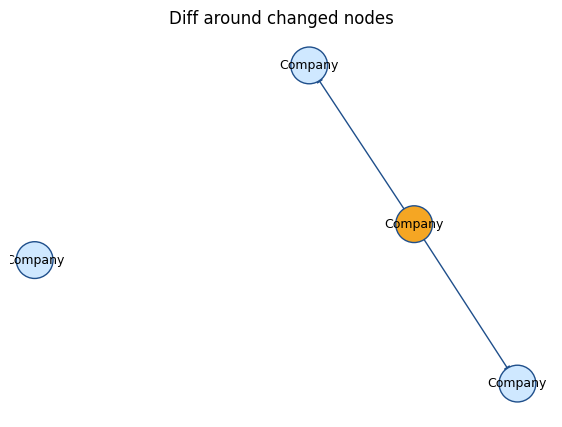

In [58]:
# Example usage
g = nx.MultiDiGraph()
g.add_node("c1", label="Company", id="100")
g.add_node("c2", label="Company", id="100")
g.add_node("p1", label="Person", id="200")
g.add_edge("p1", "c1", relation="WORKS_AT")
g.add_edge("p1", "c2", relation="WORKS_AT")

g_before = g.copy()

agent = ChaosAgent(model_name=None, seed=7)
ops = agent.plan(g, max_ops=3)
results = agent.apply(g, ops)

print(ops)
print(results)
print(graph_summary(g))

sub_before, sub_after = subgraph_around_changes(g_before, g, radius=1)
graph_diff_view(sub_before, sub_after, "Diff around changed nodes")


### 2. DBPedia

Violation score: 2921
{'domain_range:headquarter': 939, 'max_out_degree(headquarter)': 1, 'domain_range:location': 1976, 'no_self_loop[location,headquarter,country]': 0, 'company_has_geo_edge': 5}
Before: nodes=2339, edges=3091, labels=[Company:775,Place:636,Location:562,City:291,Country:72,Organisation:3]
Ops: [CorruptionOp(kind='schema_drift', params={'from_label': 'Place', 'to_label': 'Company', 'p': 1.0}), CorruptionOp(kind='entity_merge', params={'node_a': '1963', 'node_b': '1964'}), CorruptionOp(kind='entity_split', params={'node': '1963', 'split_ratio': 0.5})]
Results: {'schema_drift': 636, 'entity_merge': 1, 'entity_split': 1}
After: nodes=2339, edges=3091, labels=[Company:1412,Location:562,City:290,Country:72,Organisation:3]


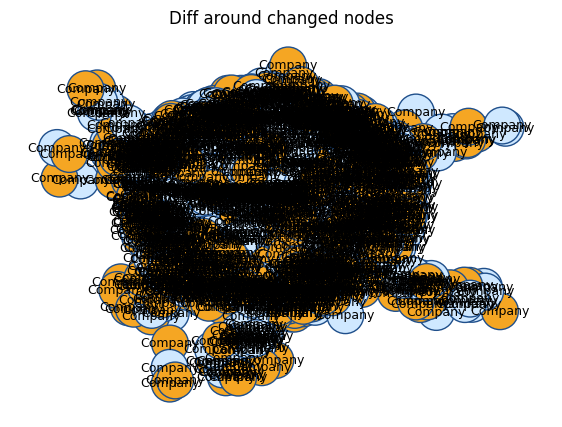

In [59]:
g = load_dbpedia_graph("dataset/dbpedia_graph.json")
C = get_constraints_for_dataset("dbpedia")

print("Violation score:", violation_score(g, C))
print({k: len(v) for k, v in violations(g, C).items()})

print("Before:", graph_summary(g))

g_before = g.copy()

agent = ChaosAgent(model_name=None, seed=3, constraints=C)
ops = agent.plan(g, max_ops=3)
results = agent.apply(g, ops)

print("Ops:", ops)
print("Results:", results)
print("After:", graph_summary(g))

sub_before, sub_after = subgraph_around_changes(g_before, g, radius=1)
graph_diff_view(sub_before, sub_after, "Diff around changed nodes")


save_graph(g, "dbpedia_corrupted_graph.json")
save_corruption_log(ops, results, "dbpedia_corruption_log.json")


## 3. FZ dataset test (ARFF)


Violation score: 56
{'symmetric[same_entity]': 0, 'no_self_loop[same_entity]': 0, 'transitive[same_entity]': 0, 'fz_city_majority[same_entity]': 52, 'fz_phone_consistency[same_entity]': 4}
Before: nodes=3401, edges=4543, labels=[Restaurant:864,Phone:857,Name:776,Addr:772,Type:83,City:49]
Ops: [CorruptionOp(kind='schema_drift', params={'from_label': 'Type', 'to_label': 'Restaurant', 'p': 1.0}), CorruptionOp(kind='entity_split', params={'node': 'fz_0', 'split_ratio': 0.5}), CorruptionOp(kind='adversarial_neighbor_rewire', params={'node': 'fz_0', 'k': 2})]
Results: {'schema_drift': 83, 'entity_split': 1, 'adversarial_neighbor_rewire': 2}
After: nodes=3402, edges=4543, labels=[Restaurant:948,Phone:857,Name:776,Addr:772,City:49]


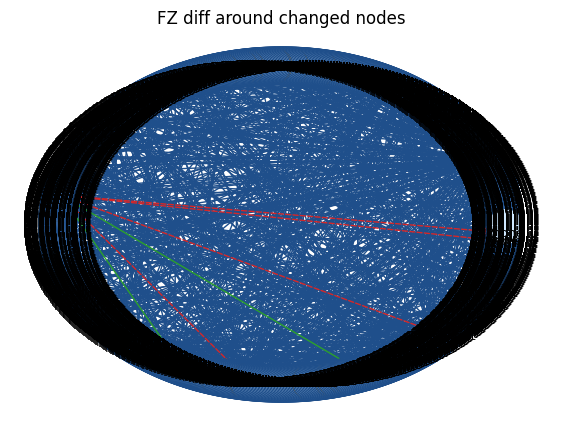

In [60]:
rows = load_fz_arff("dataset/fz.arff")
g = build_fz_graph(rows)
C = get_constraints_for_dataset("fz")
print("Violation score:", violation_score(g, C))
print({k: len(v) for k, v in violations(g, C).items()})

print("Before:", graph_summary(g))

g_before = g.copy()

agent = ChaosAgent(model_name=None, seed=3)
ops = agent.plan(g, max_ops=3, constraints=C)
results = agent.apply(g, ops)

print("Ops:", ops)
print("Results:", results)
print("After:", graph_summary(g))

sub_before, sub_after = subgraph_around_changes(g_before, g, radius=1)
g_union = nx.compose(sub_before, sub_after)
pos = nx.circular_layout(g_union)
graph_diff_view(sub_before, sub_after, "FZ diff around changed nodes", pos=pos)

save_graph(g, "fz_corrupted_graph.json")
save_corruption_log(ops, results, "fz_corruption_log.json")


## Evaluation

This section adds **repeatable evaluation utilities** for the current notebook, without changing any existing logic.

We report:

- **Violated constraints**: total + per-constraint counts (before vs after).
- **Violation diversity**: how many *distinct* constraints are violated.
- **Violations per edit**: increase in violations divided by number of applied corruption ops.
- **Comparison with random corruption**: run multiple random plans and compare against a stronger "best-of-N" (budgeted adversary) selection that chooses the plan with highest post-corruption violation score under the same budget.


In [61]:
from dataclasses import dataclass
from typing import Dict, List, Any, Optional, Tuple
import copy
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Evaluation helpers
# ------------------------------------------------------------

def violation_breakdown(g, C) -> Dict[str, int]:
    """Return {constraint_name: #violations} for graph g under constraints C."""
    vmap = violations(g, C)
    return {k: len(v) for k, v in vmap.items()}

def violation_diversity(breakdown: Dict[str, int]) -> int:
    """Number of distinct constraints with at least 1 violation."""
    return sum(1 for _, c in breakdown.items() if c > 0)

def summarize_before_after(g_before, g_after, C) -> pd.DataFrame:
    """DataFrame with per-constraint before/after counts and delta."""
    b = violation_breakdown(g_before, C)
    a = violation_breakdown(g_after, C)
    keys = sorted(set(b) | set(a))
    rows = []
    for k in keys:
        rows.append({
            "constraint": k,
            "before": int(b.get(k, 0)),
            "after": int(a.get(k, 0)),
            "delta": int(a.get(k, 0) - b.get(k, 0)),
        })
    df = pd.DataFrame(rows).sort_values(["delta", "after"], ascending=False).reset_index(drop=True)
    return df

@dataclass
class RunMetrics:
    total_before: int
    total_after: int
    delta_total: int
    diversity_before: int
    diversity_after: int
    delta_diversity: int
    applied_ops: int
    violations_per_edit: float
    per_constraint: pd.DataFrame

def evaluate_run(g_before, g_after, C, applied_ops: int) -> RunMetrics:
    """Compute the metrics requested for one corruption run."""
    b = violation_breakdown(g_before, C)
    a = violation_breakdown(g_after, C)
    total_before = sum(b.values())
    total_after = sum(a.values())
    delta_total = total_after - total_before

    div_before = violation_diversity(b)
    div_after = violation_diversity(a)
    delta_div = div_after - div_before

    vpe = float(delta_total / applied_ops) if applied_ops > 0 else float('nan')
    df = summarize_before_after(g_before, g_after, C)

    return RunMetrics(
        total_before=total_before,
        total_after=total_after,
        delta_total=delta_total,
        diversity_before=div_before,
        diversity_after=div_after,
        delta_diversity=delta_div,
        applied_ops=applied_ops,
        violations_per_edit=vpe,
        per_constraint=df,
    )

# ------------------------------------------------------------
# Planning baselines (no changes to ChaosAgent)
# ------------------------------------------------------------

def run_corruption_once(
    g,
    C,
    max_ops: int,
    seed: int,
    allowed_ops: Optional[List[str]] = None,
    only_if_increases_violations: bool = True,
) -> Tuple[RunMetrics, Dict[str, Any]]:
    """Run 1 corruption episode with a fresh agent (for reproducibility)."""
    g_before = g.copy()
    g_work = g.copy()

    agent = ChaosAgent(model_name=None, seed=seed)

    ops = agent.plan(
        g_work,
        max_ops=max_ops,
        allowed_ops=allowed_ops
    )

    result = agent.apply(
        g_work,
        ops,
        constraints=C,
        only_if_increases_violations=only_if_increases_violations,
    )

    # Count applied ops from result in a robust way:
    applied = result.get("applied_ops") or result.get("applied") or []
    applied_ops = len(applied) if isinstance(applied, list) else int(result.get("applied_count", 0))

    metrics = evaluate_run(g_before, g_work, C, applied_ops=applied_ops)
    info = {
        "seed": seed,
        "max_ops": max_ops,
        "allowed_ops": allowed_ops,
        "only_if_increases_violations": only_if_increases_violations,
        "planned_ops": ops,
        "apply_result": result,
    }
    return metrics, info

def best_of_n_plans(
    g,
    C,
    max_ops: int,
    n: int = 20,
    seed_start: int = 0,
    allowed_ops: Optional[List[str]] = None,
    only_if_increases_violations: bool = True,
) -> Tuple[RunMetrics, Dict[str, Any]]:
    """Budgeted adversary: sample N random plans (via different seeds) and keep the worst-case (highest violation score)."""
    best = None
    best_info = None

    for i in range(n):
        seed = seed_start + i
        m, info = run_corruption_once(
            g, C, max_ops=max_ops, seed=seed,
            allowed_ops=allowed_ops,
            only_if_increases_violations=only_if_increases_violations,
        )
        if best is None or m.total_after > best.total_after:
            best = m
            best_info = info

    best_info["selection"] = f"best_of_{n}"
    return best, best_info

def random_baseline_stats(
    g,
    C,
    max_ops: int,
    n: int = 20,
    seed_start: int = 0,
    allowed_ops: Optional[List[str]] = None,
    only_if_increases_violations: bool = True,
) -> pd.DataFrame:
    """Run N random trials and return summary stats in a DataFrame."""
    rows = []
    for i in range(n):
        seed = seed_start + i
        m, _ = run_corruption_once(
            g, C, max_ops=max_ops, seed=seed,
            allowed_ops=allowed_ops,
            only_if_increases_violations=only_if_increases_violations,
        )
        rows.append({
            "seed": seed,
            "total_before": m.total_before,
            "total_after": m.total_after,
            "delta_total": m.delta_total,
            "diversity_before": m.diversity_before,
            "diversity_after": m.diversity_after,
            "delta_diversity": m.delta_diversity,
            "applied_ops": m.applied_ops,
            "violations_per_edit": m.violations_per_edit,
        })
    df = pd.DataFrame(rows)
    return df

def summarize_trials(df: pd.DataFrame) -> pd.DataFrame:
    """Pretty summary (mean/std/min/max) for key metrics."""
    cols = [
        "total_after",
        "delta_total",
        "diversity_after",
        "delta_diversity",
        "applied_ops",
        "violations_per_edit",
    ]
    summary = []
    for c in cols:
        s = df[c].dropna()
        summary.append({
            "metric": c,
            "mean": float(s.mean()),
            "std": float(s.std(ddof=1)) if len(s) > 1 else 0.0,
            "min": float(s.min()),
            "max": float(s.max()),
        })
    return pd.DataFrame(summary)

# ------------------------------------------------------------
# Example: DBpedia evaluation
# ------------------------------------------------------------
try:
    g_db = load_dbpedia_graph("dataset/dbpedia_graph.json")
    C_db = get_constraints_for_dataset("dbpedia")
    print("DBpedia graph:", graph_summary(g_db))
    print("Baseline violations:", violation_score(g_db, C_db))

    # Random baseline (N trials)
    trials_db = random_baseline_stats(g_db, C_db, max_ops=3, n=20, seed_start=0)
    display(trials_db.head(5))
    display(summarize_trials(trials_db))

    # Best-of-N (stronger adversary under same budget)
    best_db, best_info_db = best_of_n_plans(g_db, C_db, max_ops=3, n=20, seed_start=0)
    print("Best-of-20 total_after:", best_db.total_after, "(delta:", best_db.delta_total, ")")
    display(best_db.per_constraint.head(10))

except Exception as e:
    print("DBpedia evaluation skipped due to error:", e)

# ------------------------------------------------------------
# Example: FZ evaluation
# ------------------------------------------------------------
try:
    rows_fz = load_fz_arff("dataset/fz.arff")
    g_fz = build_fz_graph(rows_fz)
    C_fz = get_constraints_for_dataset("fz")
    print("FZ graph:", graph_summary(g_fz))
    print("Baseline violations:", violation_score(g_fz, C_fz))

    trials_fz = random_baseline_stats(g_fz, C_fz, max_ops=3, n=20, seed_start=100)
    display(trials_fz.head(5))
    display(summarize_trials(trials_fz))

    best_fz, best_info_fz = best_of_n_plans(g_fz, C_fz, max_ops=3, n=20, seed_start=100)
    print("Best-of-20 total_after:", best_fz.total_after, "(delta:", best_fz.delta_total, ")")
    display(best_fz.per_constraint.head(10))

except Exception as e:
    print("FZ evaluation skipped due to error:", e)


DBpedia graph: nodes=2339, edges=3091, labels=[Company:775,Place:636,Location:562,City:291,Country:72,Organisation:3]
Baseline violations: 2921


,seed,total_before,total_after,delta_total,diversity_before,diversity_after,delta_diversity,applied_ops,violations_per_edit
0,0,2921,3558,637,4,5,1,0,NaN
1,1,2921,2922,1,4,5,1,0,NaN
2,2,2921,2922,1,4,5,1,0,NaN
3,3,2921,3558,637,4,5,1,0,NaN
4,4,2921,3557,636,4,4,0,0,NaN


,metric,mean,std,min,max
0,total_after,3303.2,319.334439,2922.0,3558.0
1,delta_total,382.2,319.334439,1.0,637.0
2,diversity_after,4.6,0.502625,4.0,5.0
3,delta_diversity,0.6,0.502625,0.0,1.0
4,applied_ops,0.0,0.000000,0.0,0.0
5,violations_per_edit,NaN,0.000000,NaN,NaN


Best-of-20 total_after: 3558 (delta: 637 )


,constraint,before,after,delta
0,company_has_geo_edge,5,641,636
1,"no_self_loop[location,headquarter,country]",0,1,1
2,domain_range:location,1976,1976,0
3,domain_range:headquarter,939,939,0
4,max_out_degree(headquarter),1,1,0


FZ graph: nodes=3401, edges=4543, labels=[Restaurant:864,Phone:857,Name:776,Addr:772,Type:83,City:49]
Baseline violations: 56


,seed,total_before,total_after,delta_total,diversity_before,diversity_after,delta_diversity,applied_ops,violations_per_edit
0,100,56,57,1,2,3,1,0,NaN
1,101,56,57,1,2,3,1,0,NaN
2,102,56,56,0,2,2,0,0,NaN
3,103,56,57,1,2,3,1,0,NaN
4,104,56,57,1,2,3,1,0,NaN


,metric,mean,std,min,max
0,total_after,57.60,1.500877,56.0,62.0
1,delta_total,1.60,1.500877,0.0,6.0
2,diversity_after,3.05,0.759155,2.0,4.0
3,delta_diversity,1.05,0.759155,0.0,2.0
4,applied_ops,0.00,0.000000,0.0,0.0
5,violations_per_edit,NaN,0.000000,NaN,NaN


Best-of-20 total_after: 61 (delta: 5 )


,constraint,before,after,delta
0,symmetric[same_entity],0,2,2
1,fz_city_majority[same_entity],52,53,1
2,fz_phone_consistency[same_entity],4,5,1
3,transitive[same_entity],0,1,1
4,no_self_loop[same_entity],0,0,0
